In [4]:
# --- Paths ---
DATA_ROOT = "/Users/istiak/Desktop/birdCLEF2025/data"
AUDIO_ROOT = f"{DATA_ROOT}/train_audio"
TRAIN_CSV = f"{DATA_ROOT}/train.csv"
TAX_CSV = f"{DATA_ROOT}/taxonomy.csv"

# --- Imports ---
import os, sys, json, math, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from tqdm import tqdm

import librosa
import librosa.display
import soundfile as sf
import matplotlib.pyplot as plt

# plotting defaults
plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.grid"] = True

# output directories
OUT_DIR = "./eda_outputs"
FIG_DIR = f"{OUT_DIR}/figs"
os.makedirs(FIG_DIR, exist_ok=True)


In [5]:
train = pd.read_csv(TRAIN_CSV)
tax = pd.read_csv(TAX_CSV)

# Expect train.csv to have: filename, primary_label, latitude, longitude, rating, collection, ...
print(train.head(3))
print(tax.head(3))

# Merge class names
meta = train.merge(
    tax[["primary_label","class_name","scientific_name","common_name"]],
    on="primary_label",
    how="left"
)
print(meta.head(3))


  primary_label secondary_labels  type              filename collection  \
0       1139490             ['']  ['']  1139490/CSA36385.ogg        CSA   
1       1139490             ['']  ['']  1139490/CSA36389.ogg        CSA   
2       1192948             ['']  ['']  1192948/CSA36358.ogg        CSA   

   rating                                                url  latitude  \
0     0.0  http://colecciones.humboldt.org.co/rec/sonidos...    7.3206   
1     0.0  http://colecciones.humboldt.org.co/rec/sonidos...    7.3206   
2     0.0  http://colecciones.humboldt.org.co/rec/sonidos...    7.3791   

   longitude        scientific_name            common_name             author  \
0   -73.7128   Ragoniella pulchella   Ragoniella pulchella  Fabio A. Sarria-S   
1   -73.7128   Ragoniella pulchella   Ragoniella pulchella  Fabio A. Sarria-S   
2   -73.7313  Oxyprora surinamensis  Oxyprora surinamensis  Fabio A. Sarria-S   

           license  
0  cc-by-nc-sa 4.0  
1  cc-by-nc-sa 4.0  
2  cc-by-nc-sa

In [6]:
SR = 32000           # expected sample rate in this competition
FRAME_LEN = 2048
HOP_LEN = 512

def audio_path_from_row(row):
    # train.csv 'filename' often stores relative path like "21038/iNat65519.ogg"
    return os.path.join(AUDIO_ROOT, str(row["filename"]))

def load_audio_safe(path, sr=SR):
    try:
        y, sr_ = librosa.load(path, sr=sr, mono=True)
        return y, sr, None
    except Exception as e:
        return None, None, str(e)

def amplitude_stats(y):
    if y is None or len(y) == 0:
        return np.nan, np.nan, np.nan
    return float(np.mean(np.abs(y))), float(np.std(y)), float(np.max(np.abs(y)))

def duration_seconds(y, sr):
    if y is None or sr is None:
        return np.nan
    return float(len(y) / sr)

def simple_vad_fraction(y, frame_length=FRAME_LEN, hop_length=HOP_LEN, thresh_db=-40.0):
    """
    Fraction of frames considered 'active' using RMS energy threshold in dB.
    """
    if y is None or len(y) == 0:
        return np.nan
    rms = librosa.feature.rms(y=y, frame_length=frame_length, hop_length=hop_length)[0]
    rms_db = librosa.amplitude_to_db(rms, ref=np.max)
    active = (rms_db > thresh_db).astype(np.float32)
    return float(active.mean()), float(np.nan_to_num(rms_db).mean())


In [7]:
# Set to None to process all rows; or set an integer to limit for quick tests
LIMIT = None  # e.g., 200

rows = meta if LIMIT is None else meta.head(LIMIT).copy()
stats = []

for i, row in tqdm(rows.iterrows(), total=len(rows), desc="Scanning audio"):
    p = audio_path_from_row(row)
    exists = os.path.exists(p)
    if not exists:
        stats.append({
            "filename": row["filename"],
            "primary_label": row["primary_label"],
            "class_name": row["class_name"],
            "path_exists": False,
            "load_error": "Missing file",
            "duration_s": np.nan,
            "amp_mean": np.nan,
            "amp_std": np.nan,
            "amp_max": np.nan,
            "vad_fraction": np.nan,
            "rms_db_mean": np.nan,
        })
        continue

    y, sr, err = load_audio_safe(p, sr=SR)
    dur = duration_seconds(y, sr)
    a_mean, a_std, a_max = amplitude_stats(y)
    vad_frac, rms_db_mean = simple_vad_fraction(y)

    stats.append({
        "filename": row["filename"],
        "primary_label": row["primary_label"],
        "class_name": row["class_name"],
        "path_exists": True,
        "load_error": err,
        "duration_s": dur,
        "amp_mean": a_mean,
        "amp_std": a_std,
        "amp_max": a_max,
        "vad_fraction": vad_frac,
        "rms_db_mean": rms_db_mean,
    })

stats_df = pd.DataFrame(stats)
stats_df.to_csv(f"{OUT_DIR}/audio_stats.csv", index=False)
stats_df.head()


Scanning audio: 100%|██████████| 28564/28564 [13:26<00:00, 35.40it/s] 


,filename,primary_label,class_name,path_exists,load_error,duration_s,amp_mean,amp_std,amp_max,vad_fraction,rms_db_mean
0,1139490/CSA36385.ogg,1139490,Insecta,True,None,98.853375,0.029210,0.046194,0.437570,0.902250,-18.348066
1,1139490/CSA36389.ogg,1139490,Insecta,True,None,96.537719,0.027773,0.044395,0.443007,0.900729,-18.372982
2,1192948/CSA36358.ogg,1192948,Insecta,True,None,116.599812,0.021092,0.034847,0.451677,0.917947,-21.493029
3,1192948/CSA36366.ogg,1192948,Insecta,True,None,105.446313,0.031781,0.049696,0.455066,0.908815,-18.770987
4,1192948/CSA36373.ogg,1192948,Insecta,True,None,103.631469,0.027662,0.044142,0.455979,0.906129,-20.076200


count    28564.000000
mean        35.352460
std         50.605647
min          0.544594
10%          5.616313
25%         10.579445
50%         20.976312
75%         41.300031
90%         76.090281
95%        110.938112
99%        232.309742
max       1774.392000
Name: duration_s, dtype: float64


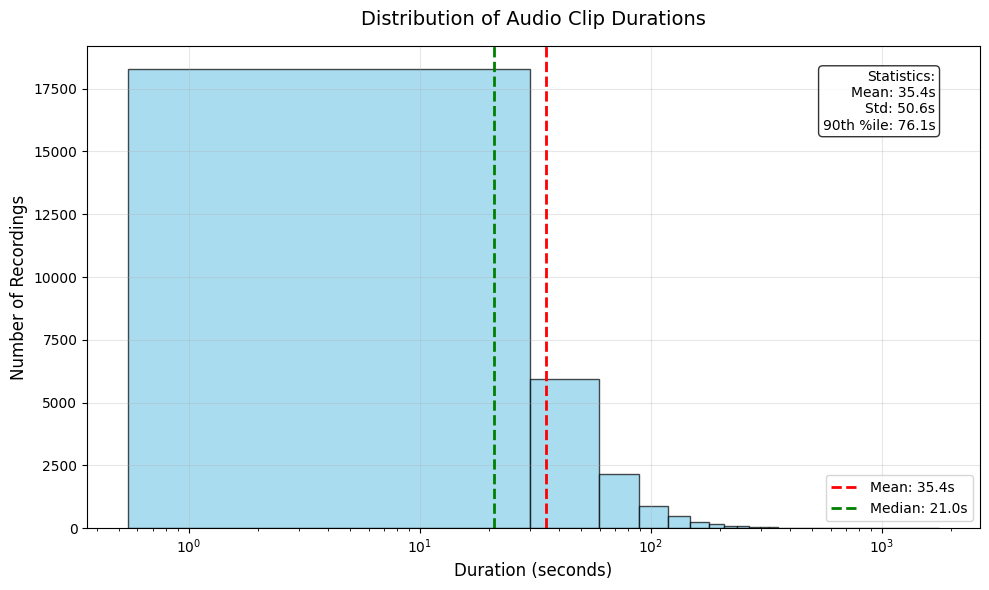

In [17]:
valid_dur = stats_df["duration_s"].dropna()
stats = valid_dur.describe(percentiles=[.1,.25,.5,.75,.9,.95,.99])
print(stats)

plt.figure(figsize=(10,6))
n, bins, patches = plt.hist(valid_dur, bins=60, color='skyblue', alpha=0.7, edgecolor='black')
plt.axvline(stats['mean'], color='red', linestyle='dashed', linewidth=2, label=f'Mean: {stats["mean"]:.1f}s')
plt.axvline(stats['50%'], color='green', linestyle='dashed', linewidth=2, label=f'Median: {stats["50%"]:.1f}s')

plt.xlabel("Duration (seconds)", fontsize=12)
plt.ylabel("Number of Recordings", fontsize=12)
plt.title("Distribution of Audio Clip Durations", fontsize=14, pad=15)
plt.grid(True, alpha=0.3)
plt.legend()

plt.xscale('log')


# Add text box with statistics
stats_text = f'Statistics:\nMean: {stats["mean"]:.1f}s\nStd: {stats["std"]:.1f}s\n90th %ile: {stats["90%"]:.1f}s'
plt.text(0.95, 0.95, stats_text, transform=plt.gca().transAxes, 
         verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/hist_durations.png", dpi=200, bbox_inches='tight')
plt.show()

Amplitude statistics:
count    4.903663e+06
mean     1.651519e-02
std      3.614297e-02
min      0.000000e+00
10%      4.303245e-04
25%      1.400080e-03
50%      4.852049e-03
75%      1.493849e-02
90%      4.048071e-02
95%      7.258233e-02
99%      1.821234e-01
max      1.098283e+00
dtype: float64


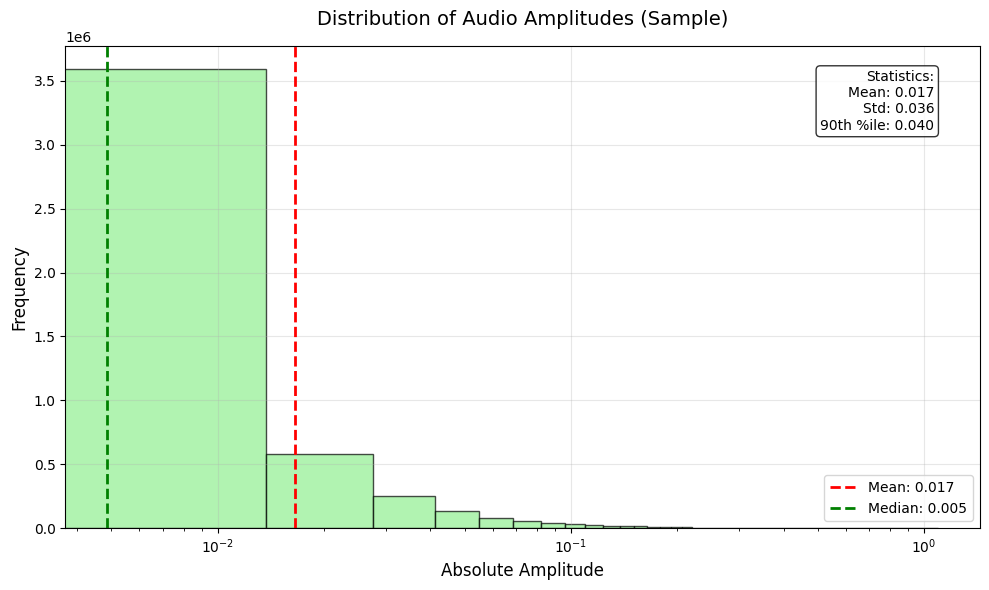

In [18]:
# Overall amplitude distribution: sample a few files to avoid gigantic arrays
SAMPLE_N = 50 if LIMIT is None else min(50, LIMIT)
sample_files = stats_df.dropna(subset=["path_exists"])
sample_files = sample_files[sample_files["path_exists"]==True].sample(min(SAMPLE_N, len(sample_files)), random_state=42)

all_vals = []
for _, r in sample_files.iterrows():
    p = os.path.join(AUDIO_ROOT, r["filename"])
    y, sr, err = load_audio_safe(p)
    if err is None and y is not None and len(y) > 0:
        # thin uniformly to reduce plotting weight
        idx = np.linspace(0, len(y)-1, num=min(100000, len(y))).astype(int)
        all_vals.append(np.abs(y[idx]))
        
if all_vals:
    vals = np.concatenate(all_vals)
    stats = pd.Series(vals).describe(percentiles=[.1,.25,.5,.75,.9,.95,.99])
    print("Amplitude statistics:")
    print(stats)
    
    plt.figure(figsize=(10,6))
    n, bins, patches = plt.hist(vals, bins=80, color='lightgreen', alpha=0.7, edgecolor='black')
    plt.axvline(stats['mean'], color='red', linestyle='dashed', linewidth=2, label=f'Mean: {stats["mean"]:.3f}')
    plt.axvline(stats['50%'], color='green', linestyle='dashed', linewidth=2, label=f'Median: {stats["50%"]:.3f}')
    
    plt.xlabel("Absolute Amplitude", fontsize=12)
    plt.ylabel("Frequency", fontsize=12)
    plt.title("Distribution of Audio Amplitudes (Sample)", fontsize=14, pad=15)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.xscale('log')
    # Add text box with statistics
    stats_text = f'Statistics:\nMean: {stats["mean"]:.3f}\nStd: {stats["std"]:.3f}\n90th %ile: {stats["90%"]:.3f}'
    plt.text(0.95, 0.95, stats_text, transform=plt.gca().transAxes, 
             verticalalignment='top', horizontalalignment='right',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.tight_layout()
    plt.savefig(f"{FIG_DIR}/hist_amplitude.png", dpi=200, bbox_inches='tight')
    plt.show()

VAD fraction statistics:
count    28564.000000
mean         0.961345
std          0.122782
min          0.021779
10%          0.928730
25%          0.986600
50%          0.997706
75%          0.999872
90%          1.000000
95%          1.000000
99%          1.000000
max          1.000000
Name: vad_fraction, dtype: float64


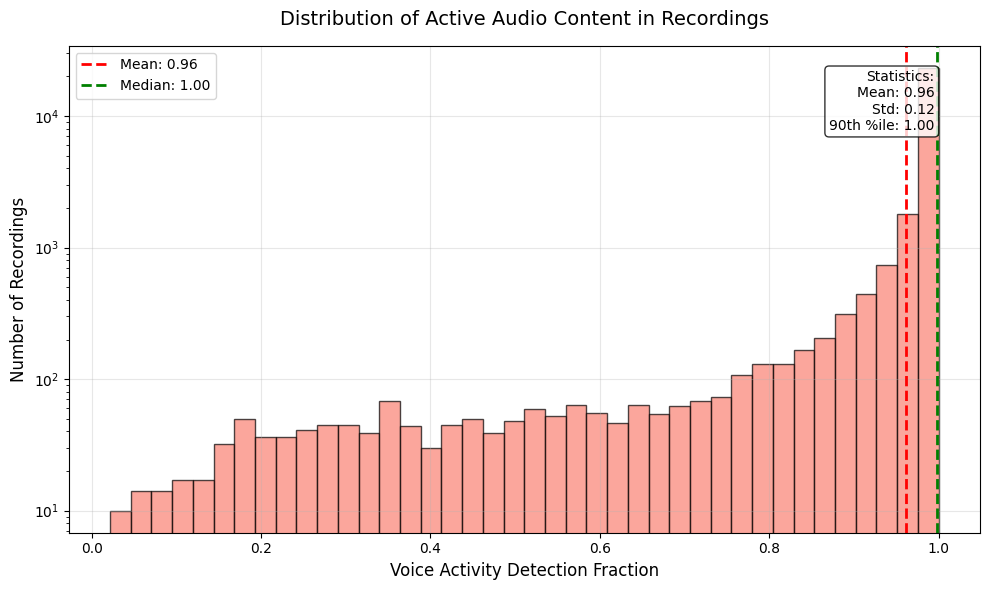

In [23]:
vad = stats_df["vad_fraction"].dropna()
stats = vad.describe(percentiles=[.1,.25,.5,.75,.9,.95,.99])
print("VAD fraction statistics:")
print(stats)

plt.figure(figsize=(10,6))
n, bins, patches = plt.hist(vad, bins=40, color='salmon', alpha=0.7, edgecolor='black')
plt.axvline(stats['mean'], color='red', linestyle='dashed', linewidth=2, label=f'Mean: {stats["mean"]:.2f}')
plt.axvline(stats['50%'], color='green', linestyle='dashed', linewidth=2, label=f'Median: {stats["50%"]:.2f}')

plt.xlabel("Voice Activity Detection Fraction", fontsize=12)
plt.ylabel("Number of Recordings", fontsize=12)
plt.title("Distribution of Active Audio Content in Recordings", fontsize=14, pad=15)
plt.grid(True, alpha=0.3)
plt.legend()
plt.yscale('log')
# Add text box with statistics
stats_text = f'Statistics:\nMean: {stats["mean"]:.2f}\nStd: {stats["std"]:.2f}\n90th %ile: {stats["90%"]:.2f}'
plt.text(0.95, 0.95, stats_text, transform=plt.gca().transAxes, 
         verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/hist_vad_fraction.png", dpi=200, bbox_inches='tight')
plt.show()

In [11]:
# ---- Robust column normalization for taxonomy + meta ----
# Inspect columns
print("train columns:", list(train.columns))
print("taxonomy columns:", list(tax.columns))

# Find the class column in taxonomy (varies across dumps)
possible_class_cols = ["class_name", "class", "Class", "taxon_class", "classLabel"]
found_class_col = next((c for c in possible_class_cols if c in tax.columns), None)

if found_class_col is None:
    raise KeyError(
        "Could not find a class column in taxonomy.csv. "
        f"Tried: {possible_class_cols}. Found: {list(tax.columns)}"
    )

# Normalize to 'class_name'
tax_norm = tax.copy()
tax_norm = tax_norm.rename(columns={found_class_col: "class_name"})

# Make sure we have these optional columns if present
extra_cols = [c for c in ["scientific_name", "common_name"] if c in tax_norm.columns]

# Also normalize primary label key if needed
# (Some variants use 'ebird_code' for birds, but BirdCLEF train.csv uses 'primary_label')
if "primary_label" not in tax_norm.columns:
    # try to infer from similar names
    possible_pl_cols = ["primary_label", "label", "ebird_code", "species_code"]
    src_pl = next((c for c in possible_pl_cols if c in tax_norm.columns), None)
    if src_pl is None:
        raise KeyError(
            "Could not find 'primary_label' (or equivalent) in taxonomy.csv. "
            f"Tried: {possible_pl_cols}. Found: {list(tax_norm.columns)}"
        )
    tax_norm = tax_norm.rename(columns={src_pl: "primary_label"})

# Rebuild meta with guaranteed 'class_name'
meta = train.merge(
    tax_norm[["primary_label", "class_name"] + extra_cols],
    on="primary_label",
    how="left"
)

# Sanity checks
assert "class_name" in meta.columns, "class_name is still missing after merge."
print(meta[["primary_label", "class_name"]].head())


train columns: ['primary_label', 'secondary_labels', 'type', 'filename', 'collection', 'rating', 'url', 'latitude', 'longitude', 'scientific_name', 'common_name', 'author', 'license']
taxonomy columns: ['primary_label', 'inat_taxon_id', 'scientific_name', 'common_name', 'class_name']
  primary_label class_name
0       1139490    Insecta
1       1139490    Insecta
2       1192948    Insecta
3       1192948    Insecta
4       1192948    Insecta


class_name
Aves        146
Amphibia     34
Insecta      17
Mammalia      9
Name: count, dtype: int64


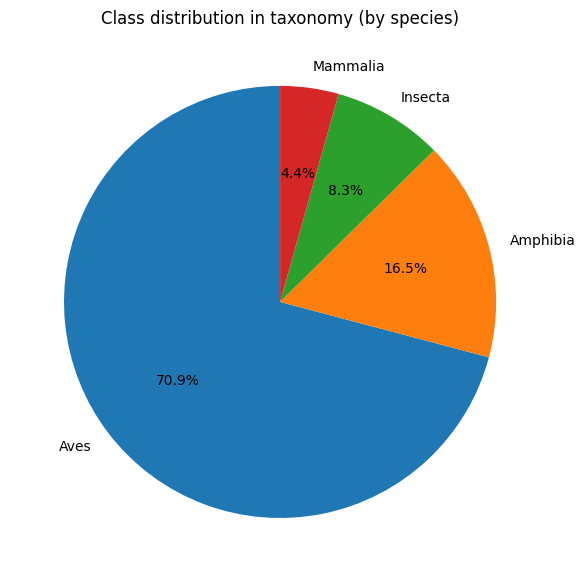

Valid location rows: 27755


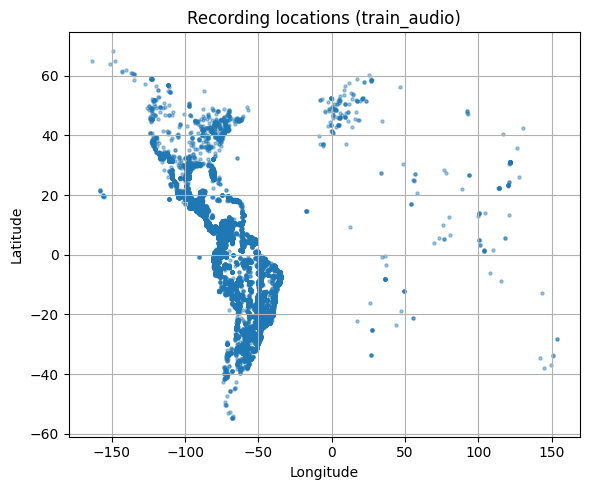

In [12]:
# Class distribution (species counts per class)
class_counts = tax["class_name"].value_counts().reindex(["Aves","Amphibia","Insecta","Mammalia"]).fillna(0)
print(class_counts)

plt.figure(figsize=(6,6))
plt.pie(class_counts.values, labels=class_counts.index, autopct="%1.1f%%", startangle=90)
plt.title("Class distribution in taxonomy (by species)")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/pie_class_distribution.png", dpi=200)
plt.show()

# Recording locations (lat/lon) — train_audio only
loc = meta[["latitude","longitude","class_name"]].dropna()
print(f"Valid location rows: {len(loc)}")

plt.figure(figsize=(6,5))
plt.scatter(loc["longitude"], loc["latitude"], s=5, alpha=0.4)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Recording locations (train_audio)")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/scatter_locations.png", dpi=200)
plt.show()


In [13]:
# Missing metadata
missing_cols = {
    "latitude": meta["latitude"].isna().sum(),
    "longitude": meta["longitude"].isna().sum(),
    "rating": meta["rating"].isna().sum() if "rating" in meta.columns else None,
    "primary_label": meta["primary_label"].isna().sum(),
}
print("Missing values:", missing_cols)

# Files referenced in CSV but missing on disk
missing_files = stats_df[(stats_df["path_exists"]==False) | (stats_df["load_error"].notna())]
print(f"Files missing or failed to load: {len(missing_files)}")
missing_files.head()

missing_files.to_csv(f"{OUT_DIR}/missing_or_unreadable_files.csv", index=False)


Missing values: {'latitude': np.int64(809), 'longitude': np.int64(809), 'rating': np.int64(0), 'primary_label': np.int64(0)}
Files missing or failed to load: 0


In [14]:
summary = {
    "n_rows_train_csv": int(len(train)),
    "n_unique_species": int(train["primary_label"].nunique()),
    "species_per_class": class_counts.to_dict(),
    "duration_sec": valid_dur.describe().to_dict(),
    "vad_fraction": vad.describe().to_dict(),
    "n_missing_or_unreadable": int(len(missing_files)),
    "n_with_location": int(loc.shape[0]),
}
with open(f"{OUT_DIR}/summary.json", "w") as f:
    json.dump(summary, f, indent=2)

summary


{'n_rows_train_csv': 28564,
 'n_unique_species': 206,
 'species_per_class': {'Aves': 146,
  'Amphibia': 34,
  'Insecta': 17,
  'Mammalia': 9},
 'duration_sec': {'count': 28564.0,
  'mean': 35.35245972859193,
  'std': 50.6056472910566,
  'min': 0.54459375,
  '25%': 10.5794453125,
  '50%': 20.9763125,
  '75%': 41.30003125,
  'max': 1774.392},
 'vad_fraction': {'count': 28564.0,
  'mean': 0.9613450884480202,
  'std': 0.12278156236239184,
  'min': 0.021778583526611328,
  '25%': 0.9865997731685638,
  '50%': 0.997706413269043,
  '75%': 0.999871551990509,
  'max': 1.0},
 'n_missing_or_unreadable': 0,
 'n_with_location': 27755}

In [15]:
per_species = train["primary_label"].value_counts().rename_axis("primary_label").reset_index(name="n_clips")
per_species.to_csv(f"{OUT_DIR}/clips_per_species.csv", index=False)
per_species.head(10)


,primary_label,n_clips
0,grekis,990
1,compau,808
2,trokin,787
3,roahaw,709
4,banana,610
5,whtdov,572
6,socfly1,543
7,yeofly1,525
8,bobfly1,514
9,wbwwre1,499


In [24]:
# analysis/mel_band_diagnostics.py
import os, random, math
import numpy as np
import matplotlib.pyplot as plt

# Optional SciPy for QQ and skew; has graceful fallback
try:
    import scipy.stats as stats
    SCIPY_OK = True
except Exception:
    SCIPY_OK = False

# --------- CONFIG ---------
MEL_DIR = "processed/feature"     # folder with *_mel.npz
FIG_DIR = "figures"
SEED = 42
MAX_FILES = 200                   # cap for speed
SELECTED_BANDS = [0, 8, 16, 24, 40, 63]  # low→high examples
HIST_BINS = 60
SAMPLE_PER_BAND = 200_000         # cap pooled samples per band
SR = 32000                        # for freq labeling if you add librosa later
# --------------------------

os.makedirs(FIG_DIR, exist_ok=True)
rng = random.Random(SEED)
np.random.seed(SEED)

# Collect file list
all_files = [os.path.join(MEL_DIR, f) for f in os.listdir(MEL_DIR) if f.endswith("_mel.npz")]
if not all_files:
    raise FileNotFoundError(f"No *_mel.npz files found in {MEL_DIR}")
files = rng.sample(all_files, k=min(MAX_FILES, len(all_files)))

# Load and pool mel bands across time/segments
# We’ll build a list per band: pooled time coefficients across many segments
band_data = [list() for _ in range(64)]

total_loaded = 0
for path in files:
    try:
        dat = np.load(path)
        mel = dat["mel"]  # shape (64, T), log-mel dB with max=0
        if mel.ndim != 2 or mel.shape[0] != 64:
            continue
        # Optionally subsample time frames to avoid huge memory
        T = mel.shape[1]
        if T > 1000:
            idx = np.linspace(0, T-1, num=1000, dtype=int)
            mel = mel[:, idx]
        for b in range(64):
            band_data[b].append(mel[b, :].astype(np.float32))
        total_loaded += 1
    except Exception as e:
        # skip corrupt/malformed files
        continue

# Concatenate per band and cap length for plotting
for b in range(64):
    if len(band_data[b]) == 0:
        band_data[b] = np.array([], dtype=np.float32)
        continue
    x = np.concatenate(band_data[b], axis=0)
    if x.size > SAMPLE_PER_BAND:
        idx = np.random.choice(x.size, size=SAMPLE_PER_BAND, replace=False)
        x = x[idx]
    band_data[b] = x

print(f"Loaded {total_loaded} files. Example pooled sizes:",
      [band_data[i].size for i in SELECTED_BANDS])

# ---------- Helper stats ----------
def safe_mean(x): return float(np.mean(x)) if x.size else np.nan
def safe_std(x):  return float(np.std(x, ddof=0)) if x.size else np.nan

def safe_skew(x):
    if x.size == 0: return np.nan
    if SCIPY_OK:
        return float(stats.skew(x, bias=False, nan_policy='omit'))
    # manual skew: m3 / s^3
    m = np.mean(x)
    s = np.std(x, ddof=0)
    if s == 0: return 0.0
    m3 = np.mean((x - m)**3)
    return float(m3 / (s**3))

# ========== FIGURE 1: Histograms with Normal PDF overlay ==========
fig, axs = plt.subplots(2, 3, figsize=(12, 6), constrained_layout=True)
axs = axs.ravel()
for ax, b in zip(axs, SELECTED_BANDS):
    x = band_data[b]
    if x.size == 0:
        ax.text(0.5, 0.5, f"Band {b}: no data", ha='center', va='center')
        ax.axis('off')
        continue
    mu, sd = safe_mean(x), safe_std(x)
    # Histogram (density)
    ax.hist(x, bins=HIST_BINS, density=True, alpha=0.6)
    # Normal overlay
    if math.isfinite(mu) and math.isfinite(sd) and sd > 0:
        xs = np.linspace(np.percentile(x, 0.5), np.percentile(x, 99.5), 400)
        norm_pdf = (1.0/(sd*np.sqrt(2*np.pi))) * np.exp(-0.5*((xs-mu)/sd)**2)
        ax.plot(xs, norm_pdf, linewidth=2)
    ax.set_title(f"Band {b}  (μ={mu:.2f}, σ={sd:.2f})")
    ax.set_xlabel("Log-Mel (dB)")
    ax.set_ylabel("Density")
fig.suptitle("Band-wise histograms (pooled across segments) with Normal overlay", y=1.02, fontsize=12)
hist_path_pdf = os.path.join(FIG_DIR, "hist_mel_bands.pdf")
hist_path_png = os.path.join(FIG_DIR, "hist_mel_bands.png")
fig.savefig(hist_path_pdf, bbox_inches='tight')
fig.savefig(hist_path_png, dpi=200, bbox_inches='tight')
plt.close(fig)

# ========== FIGURE 2: QQ plots vs Normal ==========
if SCIPY_OK:
    fig, axs = plt.subplots(2, 3, figsize=(12, 6), constrained_layout=True)
    axs = axs.ravel()
    for ax, b in zip(axs, SELECTED_BANDS):
        x = band_data[b]
        if x.size == 0:
            ax.text(0.5, 0.5, f"Band {b}: no data", ha='center', va='center')
            ax.axis('off')
            continue
        stats.probplot(x, dist="norm", plot=ax)
        ax.set_title(f"Q–Q plot (Band {b})")
    fig.suptitle("Q–Q plots vs Normal for selected Mel bands", y=1.02, fontsize=12)
    qq_path_pdf = os.path.join(FIG_DIR, "qq_mel_bands.pdf")
    qq_path_png = os.path.join(FIG_DIR, "qq_mel_bands.png")
    fig.savefig(qq_path_pdf, bbox_inches='tight')
    fig.savefig(qq_path_png, dpi=200, bbox_inches='tight')
    plt.close(fig)
else:
    print("SciPy not available: skipping Q–Q plots.")

# ========== FIGURE 3: Skewness across all 64 bands ==========
skews = np.array([safe_skew(band_data[b]) for b in range(64)], dtype=float)
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.bar(np.arange(64), skews)
ax.axhline(0.0, linestyle="--", linewidth=1)
ax.set_xlabel("Mel band index (0–63)")
ax.set_ylabel("Skewness")
ax.set_title("Skewness of log–Mel coefficients across bands (pooled)")
skew_path_pdf = os.path.join(FIG_DIR, "skewness_mel_bands.pdf")
skew_path_png = os.path.join(FIG_DIR, "skewness_mel_bands.png")
fig.savefig(skew_path_pdf, bbox_inches='tight')
fig.savefig(skew_path_png, dpi=200, bbox_inches='tight')
plt.close(fig)

# ========== CSV summary: mu, sigma, skew per band ==========
summary = np.zeros((64, 3), dtype=float)
for b in range(64):
    x = band_data[b]
    summary[b, 0] = safe_mean(x)
    summary[b, 1] = safe_std(x)
    summary[b, 2] = safe_skew(x)

csv_path = os.path.join(FIG_DIR, "mel_band_summary_mu_sigma_skew.csv")
np.savetxt(csv_path, summary, delimiter=",", header="mu,sigma,skew", comments="")
print("Saved files:")
print(" -", hist_path_pdf)
print(" -", hist_path_png)
if SCIPY_OK:
    print(" -", qq_path_pdf)
    print(" -", qq_path_png)
print(" -", skew_path_pdf)
print(" -", skew_path_png)
print(" -", csv_path)


Loaded 200 files. Example pooled sizes: [62600, 62600, 62600, 62600, 62600, 62600]
Saved files:
 - figures/hist_mel_bands.pdf
 - figures/hist_mel_bands.png
 - figures/qq_mel_bands.pdf
 - figures/qq_mel_bands.png
 - figures/skewness_mel_bands.pdf
 - figures/skewness_mel_bands.png
 - figures/mel_band_summary_mu_sigma_skew.csv
